In [5]:
pip install numpy scipy matplotlib tqdm ipywidgets pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from ffnn.nn import MLP, Layer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
# Dataframe
df = pd.read_csv('../data/datasetml_2026.csv')
df

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8.040882,0,Tier 3,USA,100-300,2,98.120449,80.866213,Data Science,Manufacturing,6.298524,Placed
9996,5.401324,3,Tier 1,UK,100-300,1,68.622854,83.458035,Data Science,Consulting,7.352717,Not Placed
9997,6.435747,0,Tier 3,UK,300+,2,69.067773,50.992745,Core CS,Other,3.871205,Placed
9998,7.396612,1,Tier 3,Germany,100-300,3,45.050463,86.807882,Cloud,Finance,3.687731,Placed


In [8]:
# Data Preprocessing

# Missing values : tidak ada
# Handling outliers ; -
# Encoding fitur kategorikal
# Ordinal Encoding 
tier_mapping = {'Tier 3': 1, 'Tier 2': 2, 'Tier 1': 3}
ranking_mapping = {'300+': 1, '100-300': 2, 'Top 100': 3}
df['college_tier'] = df['college_tier'].map(tier_mapping)
df['university_ranking_band'] = df['university_ranking_band'].map(ranking_mapping)

# Label Encoding 
target_mapping = {'Not Placed': 0, 'Placed': 1}
df['placement_status'] = df['placement_status'].map(target_mapping)

# One-Hot Encoding
nom_cols = ['country', 'specialization', 'industry']
df_final = pd.get_dummies(df, columns=nom_cols, drop_first=True, dtype=int) 

# Feature scaling
scaler = StandardScaler()
cols_to_scaled = ['cgpa', 'aptitude_score', 'communication_score', 'internship_quality_score']
df_final[cols_to_scaled] = scaler.fit_transform(df_final[cols_to_scaled])

# Train-test
X = df_final.drop('placement_status', axis=1).values 
y = df_final['placement_status'].values 
X_train, X_val, y_train, y_val = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

# Test

In [9]:
model = MLP([
    Layer(64, activation='gelu', weight_init='he'),
    Layer(1, activation='softmax', weight_init='xavier')
], input_size=X_train.shape[1])

model.compile(optimizer='sgd', loss='bce')
history = model.fit(
    X_train, y_train,
    batch_size = 32,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1
)



Training FFNN:   0%|          | 0/100 [00:00<?, ?it/s]

# Hyperparameter

## Pengaruh depth (banyak layer) dan width (banyak neuron per layer)
- Pilih 3 variasi kombinasi width (depth tetap) dan 3 variasi depth (width semua layer tetap)
- Bandingkan hasil akhir prediksinya
- Bandingkan grafik training loss dan validation loss tiap epoch setelah pelatihan

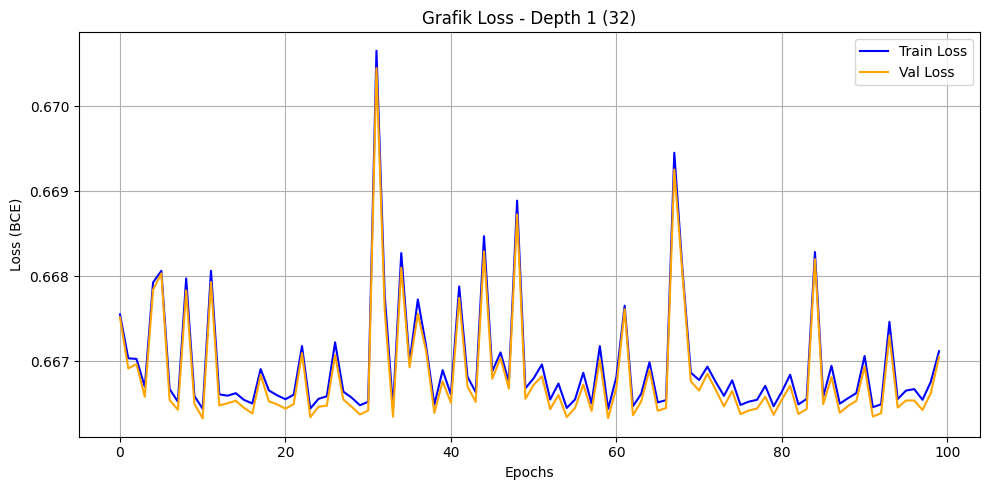

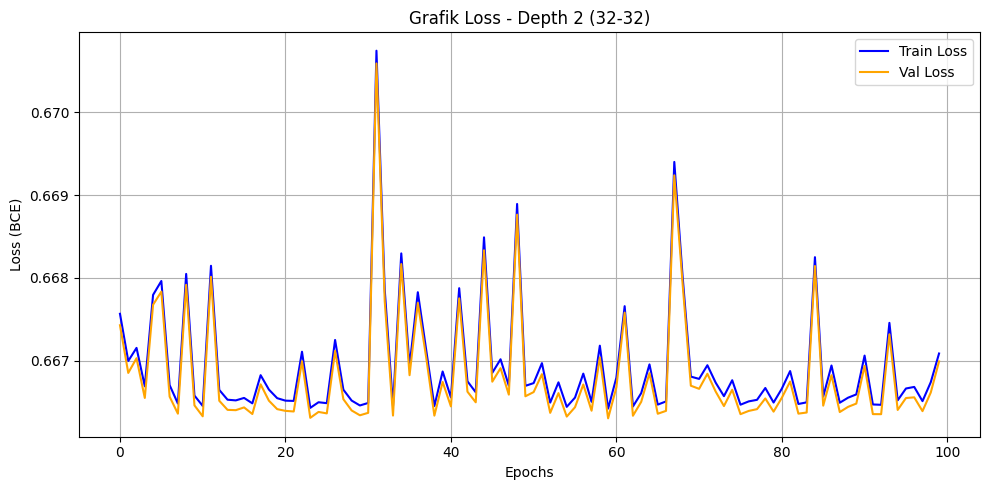

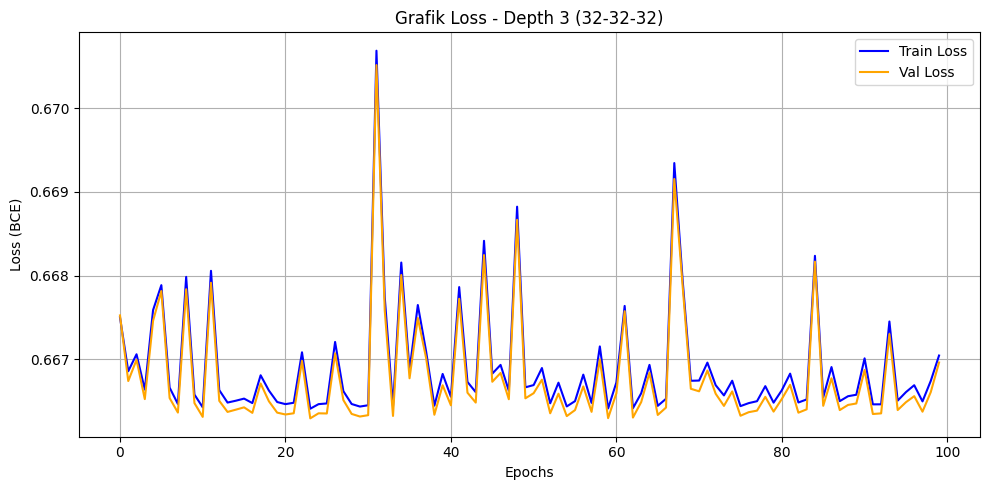

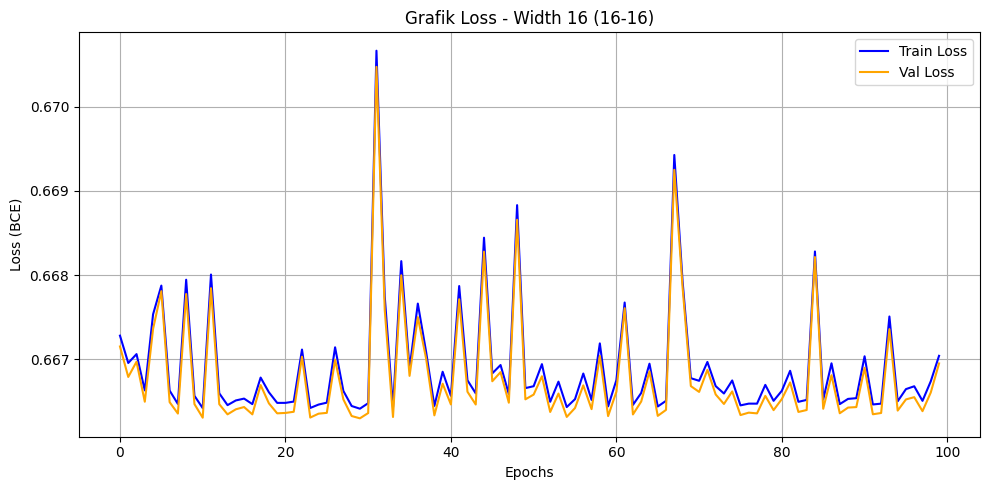

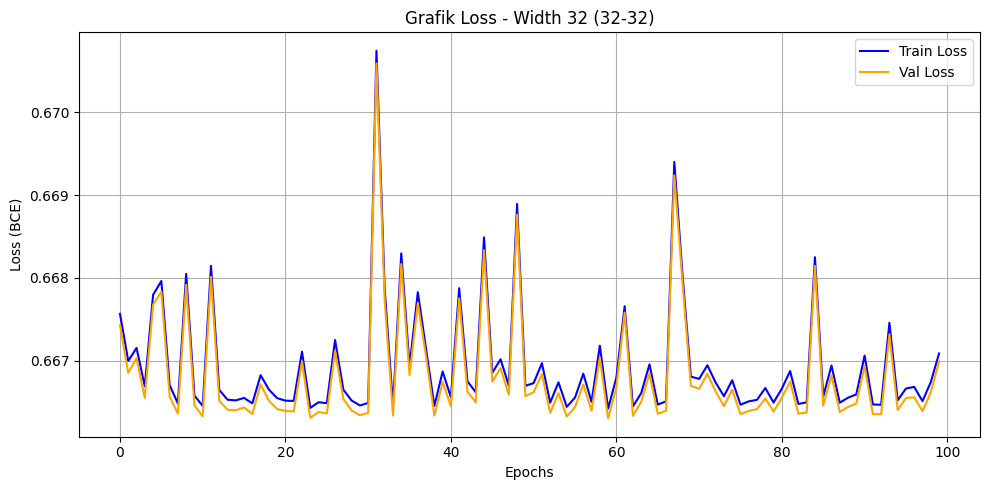

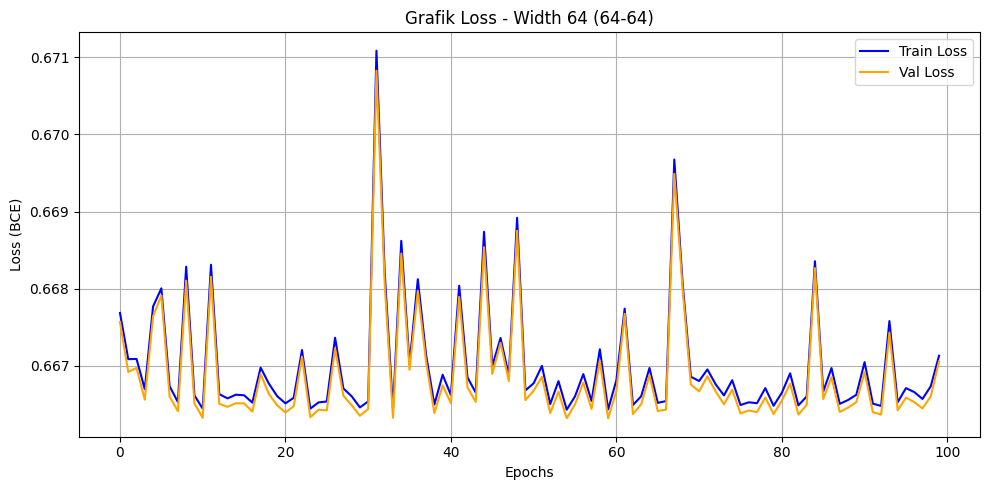

In [10]:
all_histories = {}

# Eksperimen Width (Depth tetap)
configs_width = {
    "Width 16 (16-16)": [16, 16],
    "Width 32 (32-32)": [32, 32],
    "Width 64 (64-64)": [64, 64] 
}

# Eksperimen Depth (Width tetap 32)
configs_depth = {
    "Depth 1 (32)": [32],
    "Depth 2 (32-32)": [32, 32],
    "Depth 3 (32-32-32)": [32, 32, 32]
}

all_configs = {**configs_depth, **configs_width}
for name, hidden_sizes in all_configs.items():
    layers = []
    for size in hidden_sizes:
        layers.append(Layer(size, activation='gelu', weight_init='he'))
    layers.append(Layer(1, activation='sigmoid', weight_init='xavier'))
    
    model = MLP(layers, input_size=X_train.shape[1], seed=42)
    model.compile(optimizer='sgd', loss='bce')

    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        verbose=0 
    )

    all_histories[name] = history

# Plot Hasil 
for name, history in all_histories.items():
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', color='blue') 
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.title(f"Grafik Loss - {name}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

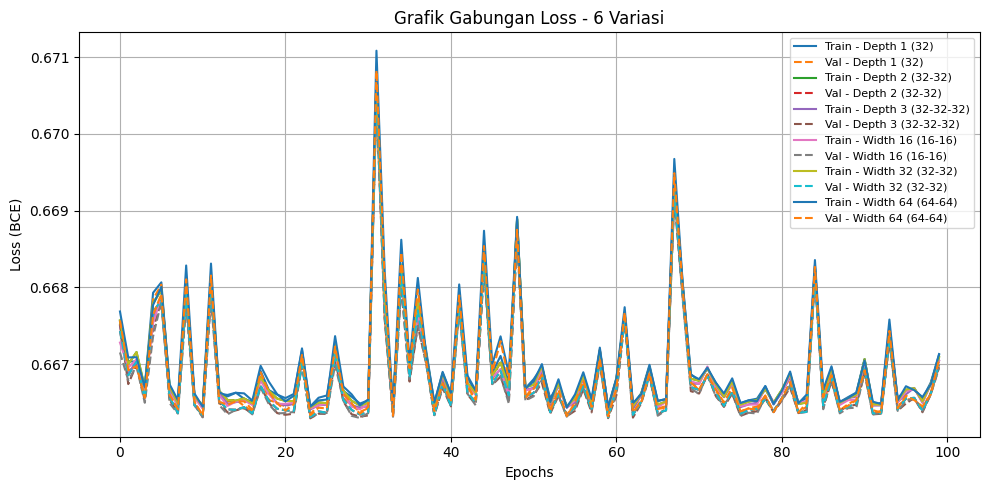

In [20]:
plt.figure(figsize=(10, 5))
for name, history in all_histories.items():
    plt.plot(history['train_loss'], label=f'Train - {name}') 
    plt.plot(history['val_loss'], label=f'Val - {name}', linestyle='--')
plt.title("Grafik Gabungan Loss - 6 Variasi")
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend(loc='upper right', fontsize=8) 
plt.grid(True)
plt.tight_layout() 
plt.show()

## Pengaruh fungsi aktivasi hidden layer
- Tentukan base arsitektur (minimal 3 layer), pilih 1 layer sebagai layer pengetesan
- Lakukan eksperimen dengan menjalankan variasi base arsitektur dengan setiap fungsi aktivasi yang diimplementasikan kecuali softmax pada layer pilihan
- Bandingkan hasil akhir prediksinya
- Bandingkan grafik training loss dan validation loss tiap epoch setelah pelatihan
- Bandingkan distribusi bobot dan gradien bobot dari beberapa/semua layer pada model

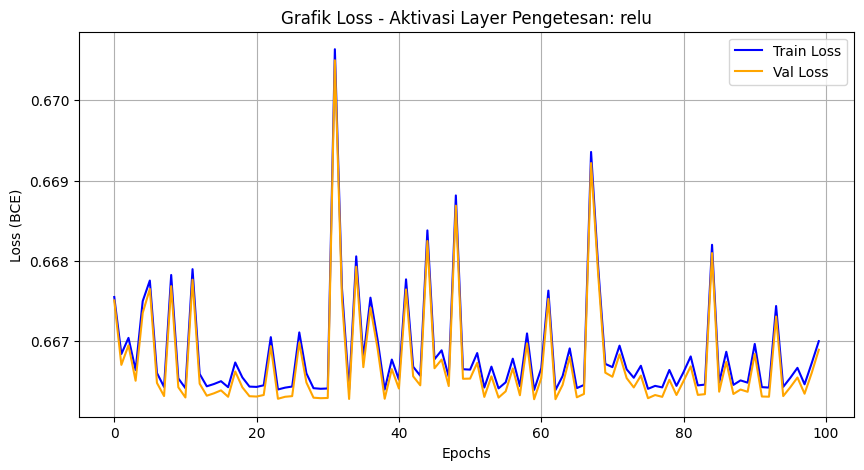

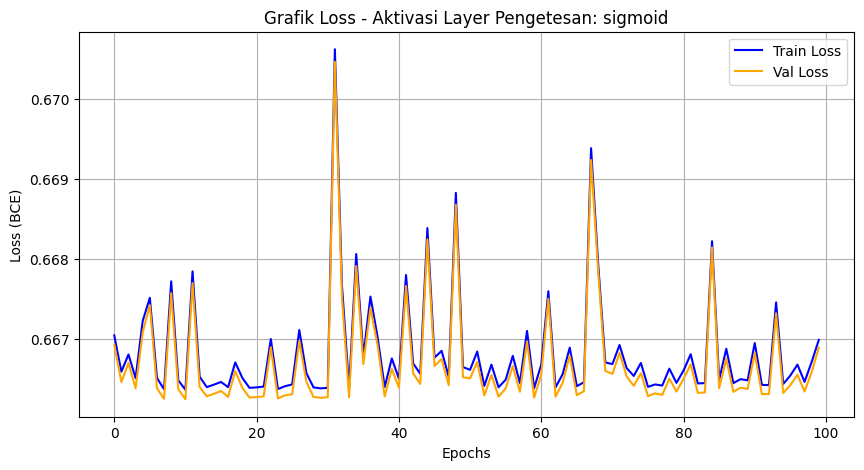

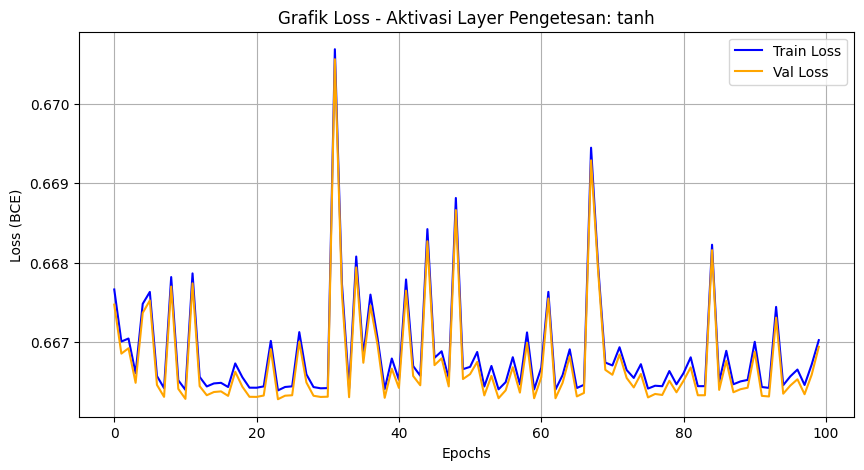

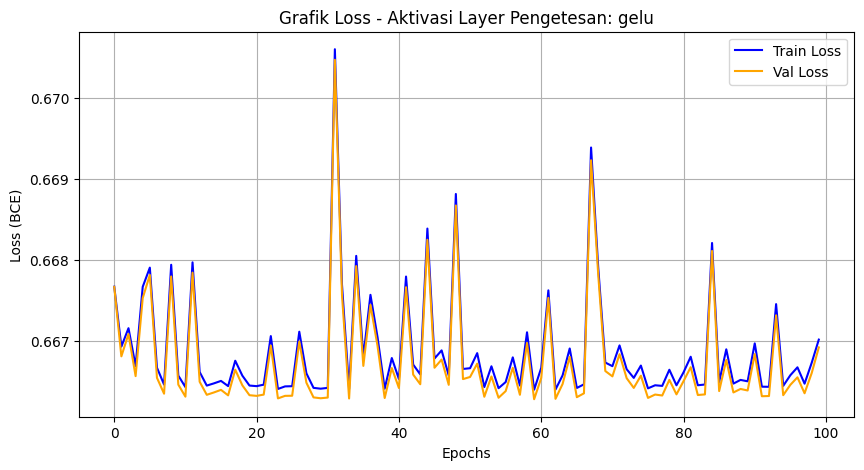

Distribusi untuk Model dengan Fungsi Aktivasi relu
Distribusi Bobot (Weights)


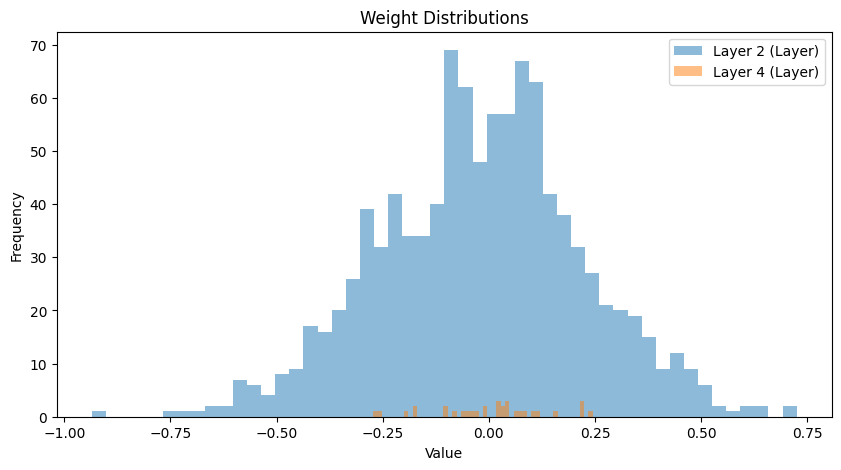

Distribusi Gradien Bobot (Gradients)


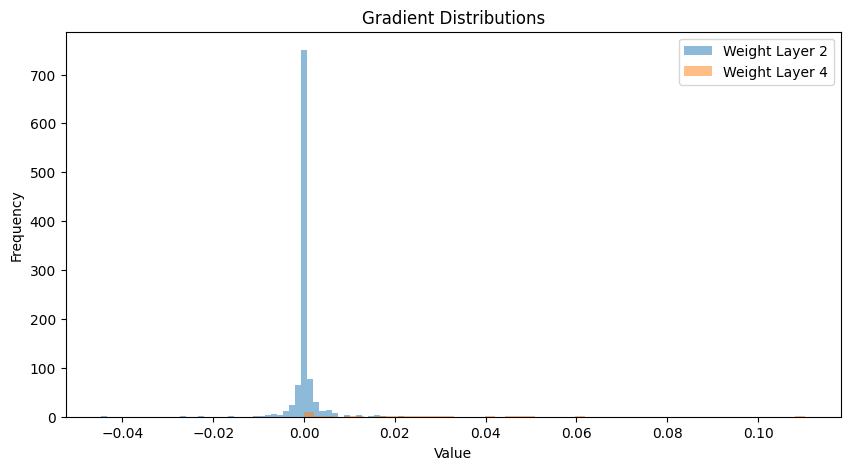

Distribusi untuk Model dengan Fungsi Aktivasi sigmoid
Distribusi Bobot (Weights)


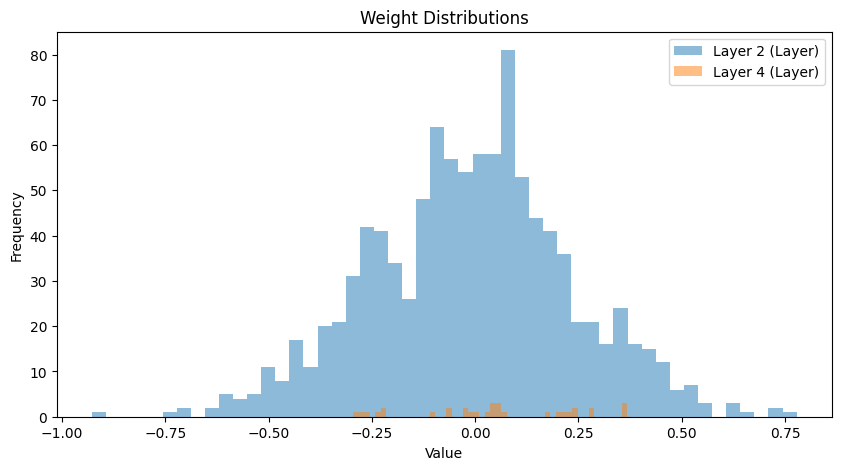

Distribusi Gradien Bobot (Gradients)


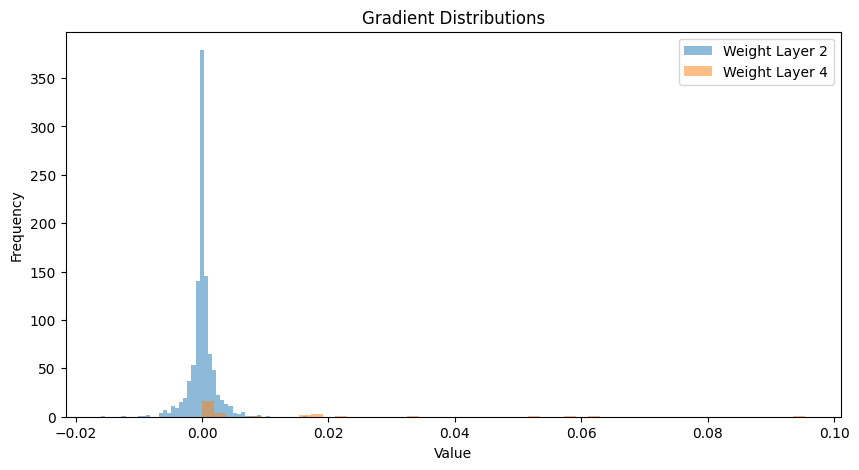

Distribusi untuk Model dengan Fungsi Aktivasi tanh
Distribusi Bobot (Weights)


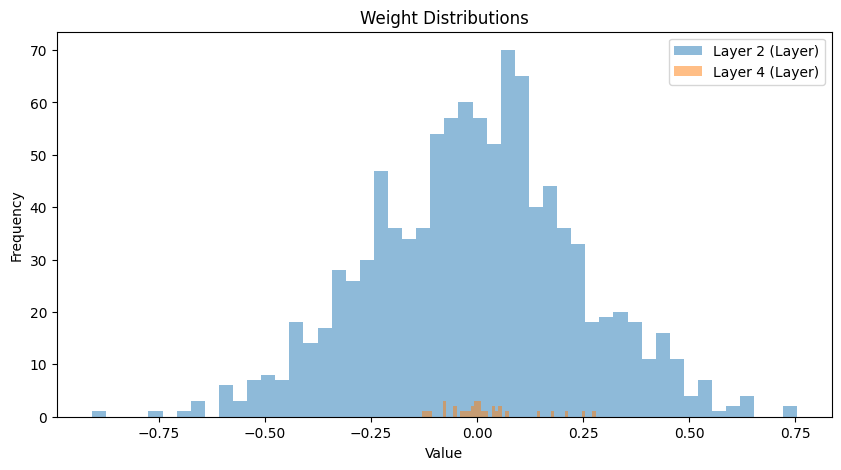

Distribusi Gradien Bobot (Gradients)


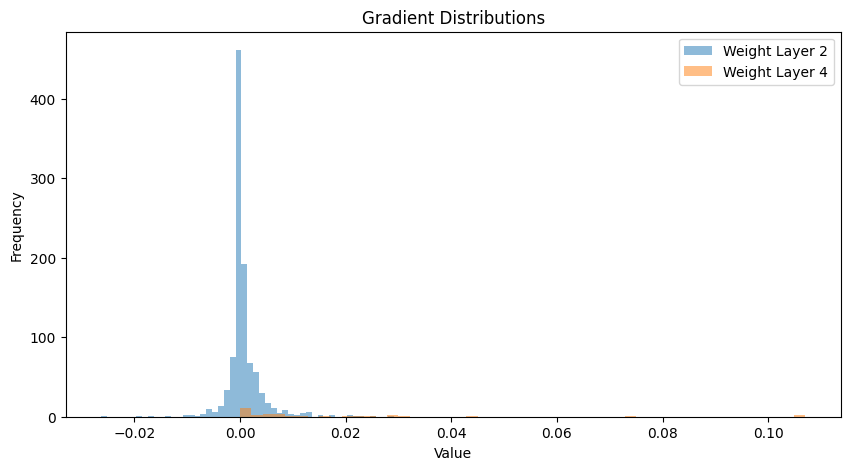

Distribusi untuk Model dengan Fungsi Aktivasi gelu
Distribusi Bobot (Weights)


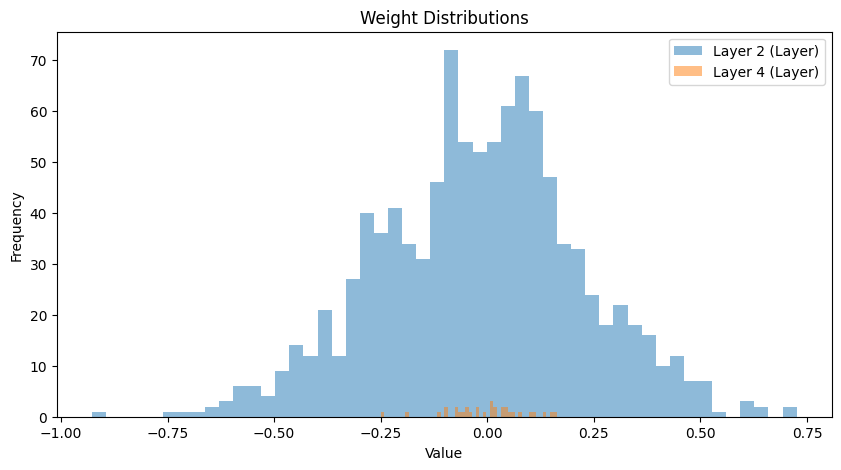

Distribusi Gradien Bobot (Gradients)


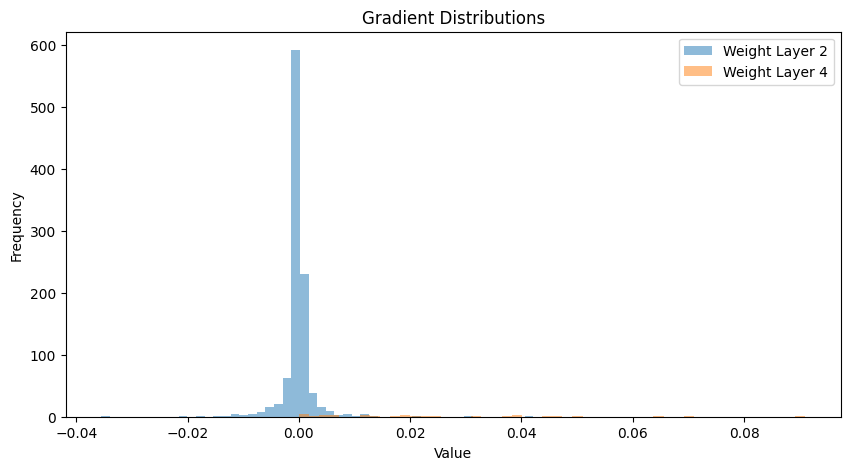

In [11]:
test_activations = ['relu', 'sigmoid', 'tanh', 'gelu']

all_histories_act = {}
trained_models = {}

for act in test_activations:
    # Base Arsitektur: 3 Hidden Layer + 1 Output Layer
    layers = [
        # Layer 1 (Fixed)
        Layer(32, activation='relu', weight_init='he'),      
        # Layer 2 (Layer Pengetesan)
        Layer(32, activation=act, weight_init='he'),         
        # Layer 3 (Fixed)
        Layer(32, activation='relu', weight_init='he'),      
        # Output Layer
        Layer(1, activation='sigmoid', weight_init='xavier') 
    ]
   
    model = MLP(layers, input_size=X_train.shape[1], seed=42)
    model.compile(optimizer='sgd', loss='bce')
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    all_histories_act[act] = history
    trained_models[act] = model

# Plot hasil
for act, history in all_histories_act.items():
    plt.figure(figsize=(10, 5)) 
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.title(f"Grafik Loss - Aktivasi Layer Pengetesan: {act}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)
    plt.show() 

# Distribusi Bobot dan Gradien
for act, model in trained_models.items():
    print(f"Distribusi untuk Model dengan Fungsi Aktivasi {act}")
    print(f"Distribusi Bobot (Weights)")
    model.plot_weights([1, 3]) 
    print(f"Distribusi Gradien Bobot (Gradients)")
    model.plot_gradients([1, 3])

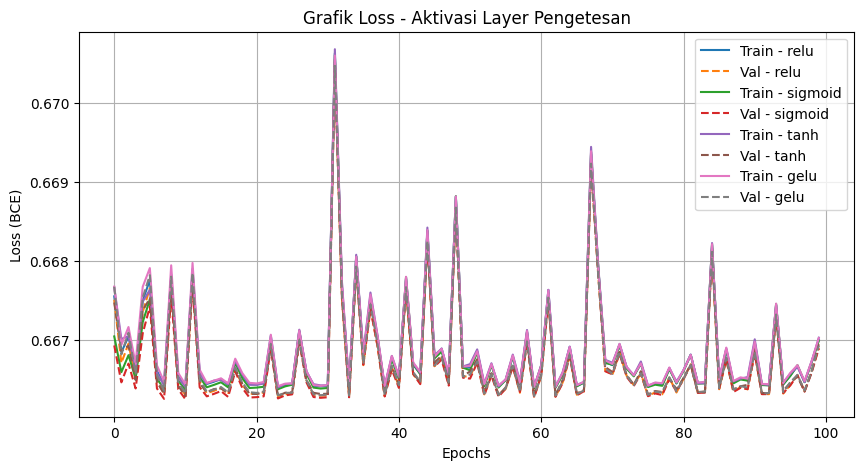

In [24]:
plt.figure(figsize=(10, 5)) 
for act, history in all_histories_act.items():
    plt.plot(history['train_loss'], label=f'Train - {act}') 
    plt.plot(history['val_loss'], label=f'Val - {act}', linestyle='--')
plt.title(f"Grafik Loss - Aktivasi Layer Pengetesan")
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(True)
plt.show() 

## Pengaruh learning rate
- Lakukan 3 variasi learning rate (nilainya dibebaskan)
- Bandingkan hasil akhir prediksinya
- Bandingkan grafik training loss dan validation loss tiap epoch setelah pelatihan
- Bandingkan distribusi bobot dan gradien bobot dari beberapa/semua layer pada model

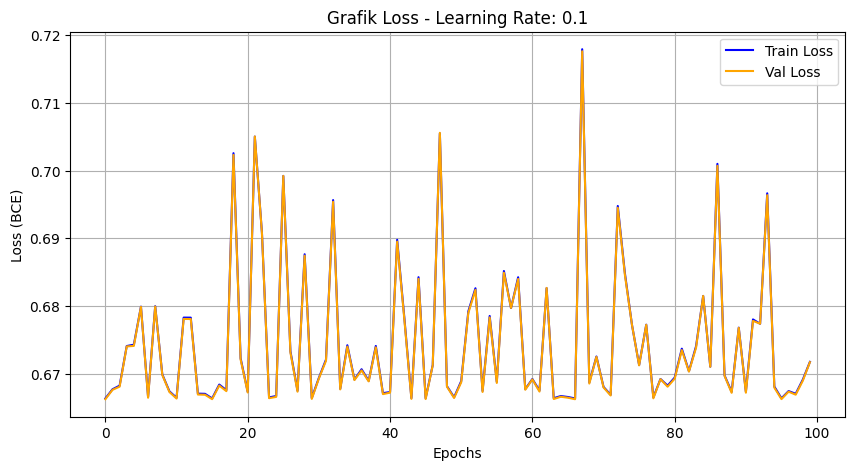

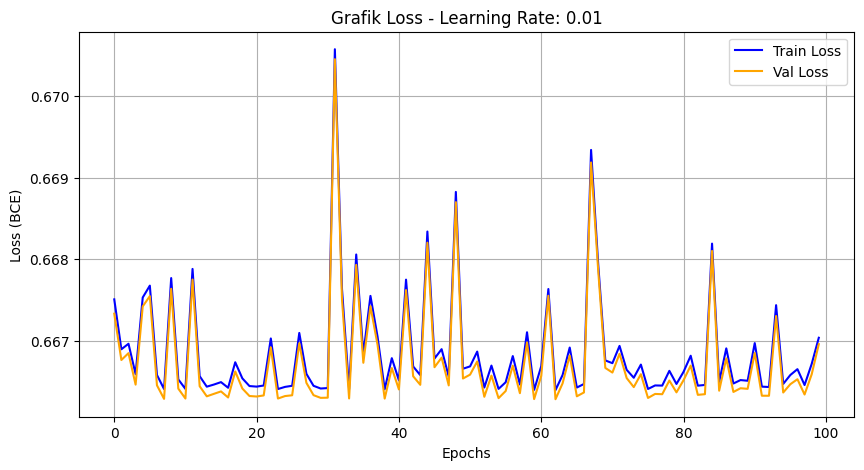

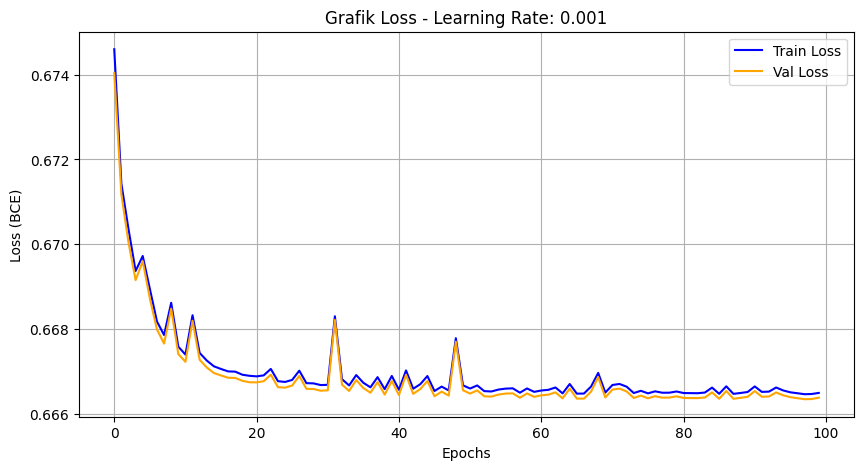

Distribusi untuk Model dengan Learning Rate 0.1
Distribusi Bobot (Weights)


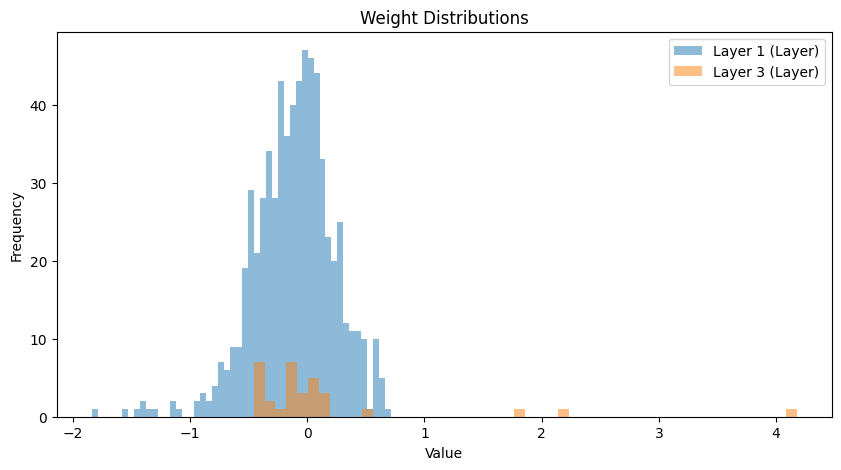

Distribusi Gradien Bobot (Gradients)


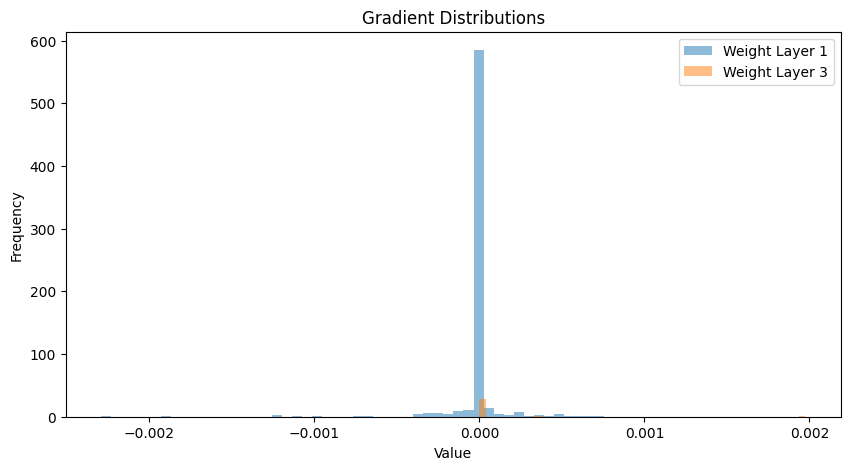

Distribusi untuk Model dengan Learning Rate 0.01
Distribusi Bobot (Weights)


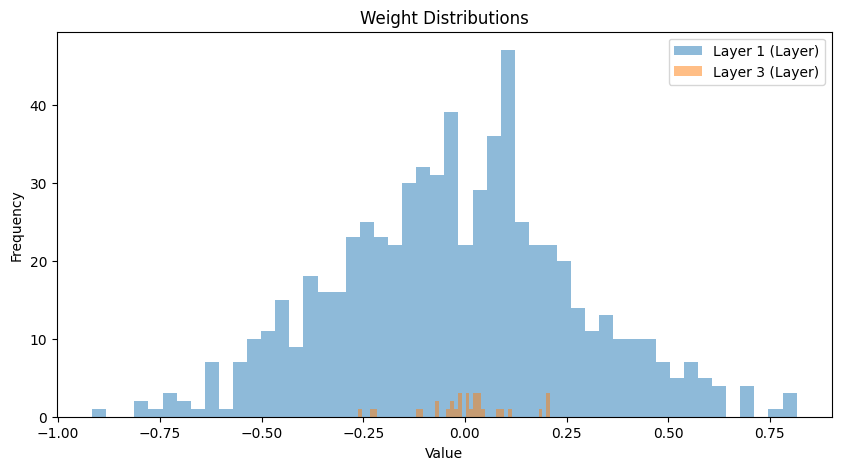

Distribusi Gradien Bobot (Gradients)


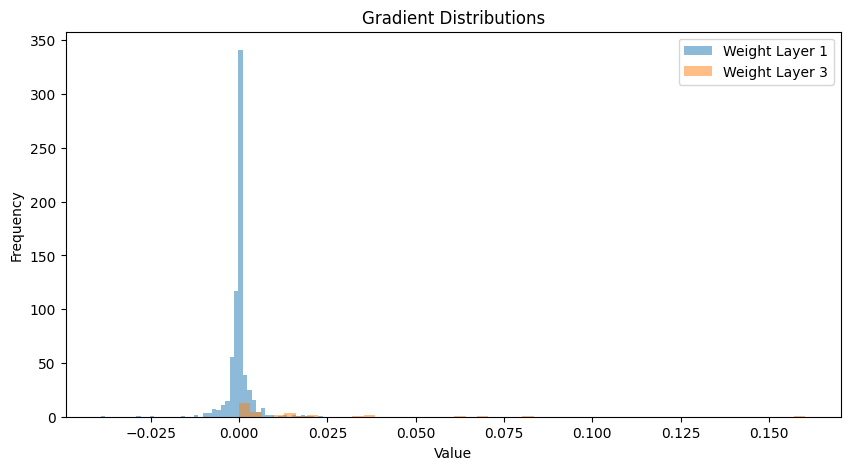

Distribusi untuk Model dengan Learning Rate 0.001
Distribusi Bobot (Weights)


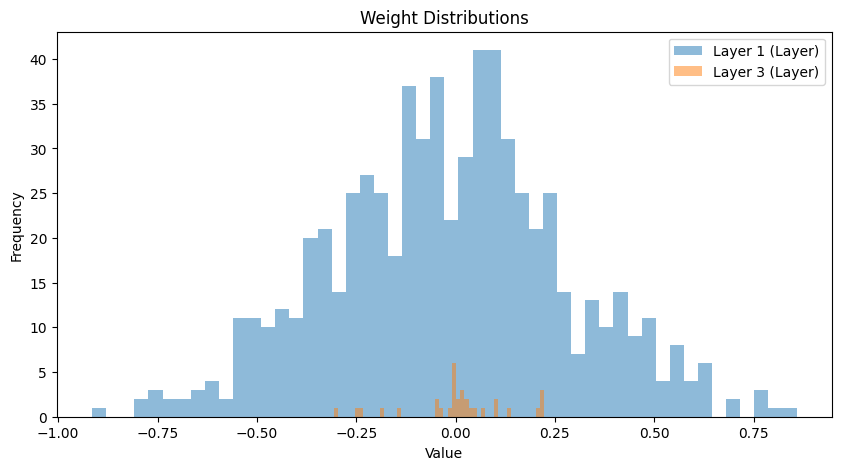

Distribusi Gradien Bobot (Gradients)


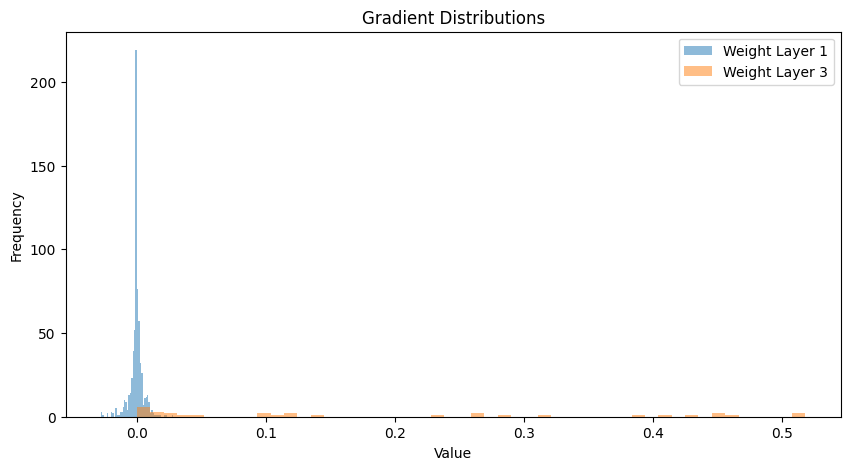

In [12]:
# Variasi learning rate
learning_rates = [0.1, 0.01, 0.001]
all_histories_lr = {}
trained_models_lr = {}

for lr in learning_rates:
    layers = [
        Layer(32, activation='relu', weight_init='he'),      
        Layer(32, activation='relu', weight_init='he'),      
        Layer(1, activation='sigmoid', weight_init='xavier') 
    ]
    
    model = MLP(layers, input_size=X_train.shape[1], seed=42)
    model.compile(optimizer={'method': 'sgd', 'learning_rate': lr}, loss='bce')
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        verbose=0
    )
    all_histories_lr[lr] = history
    trained_models_lr[lr] = model

# Plot hasil
for lr, history in all_histories_lr.items():
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.title(f"Grafik Loss - Learning Rate: {lr}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)
    plt.show() 

# Distribusi Bobot dan Gradien
for lr, model in trained_models_lr.items():
    print(f"Distribusi untuk Model dengan Learning Rate {lr}")
    print(f"Distribusi Bobot (Weights)")
    model.plot_weights([0, 2]) 
    print(f"Distribusi Gradien Bobot (Gradients)")
    model.plot_gradients([0, 2])

    

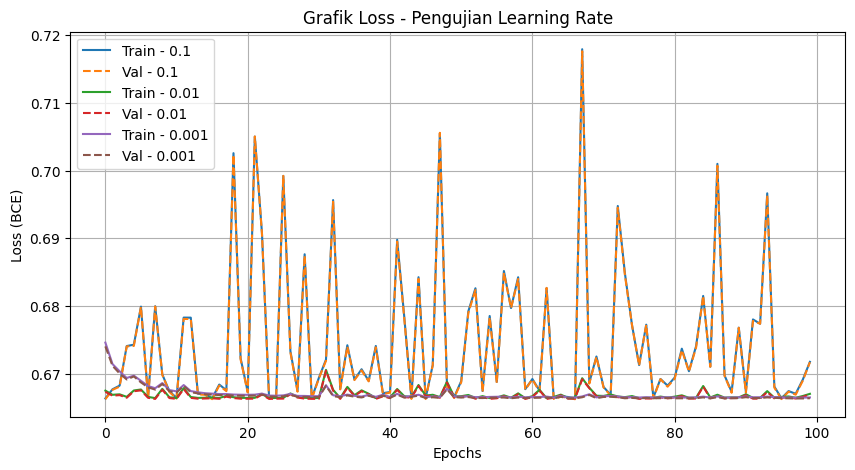

In [25]:
plt.figure(figsize=(10, 5)) 
for lr, history in all_histories_lr.items():
    plt.plot(history['train_loss'], label=f'Train - {lr}') 
    plt.plot(history['val_loss'], label=f'Val - {lr}', linestyle='--')
plt.title(f"Grafik Loss - Pengujian Learning Rate")
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(True)
plt.show() 

# Pengaruh Regularisasi
- Lakukan eksperimen masing-masing 1 kali untuk model tanpa regularisasi, dengan regularisasi L1, dan dengan regularisasi L2
- Bandingkan hasil akhir prediksinya
- Bandingkan grafik training loss dan validation loss tiap epoch setelah pelatihan
- Bandingkan distribusi bobot dan gradien bobot dari beberapa/semua layer pada model

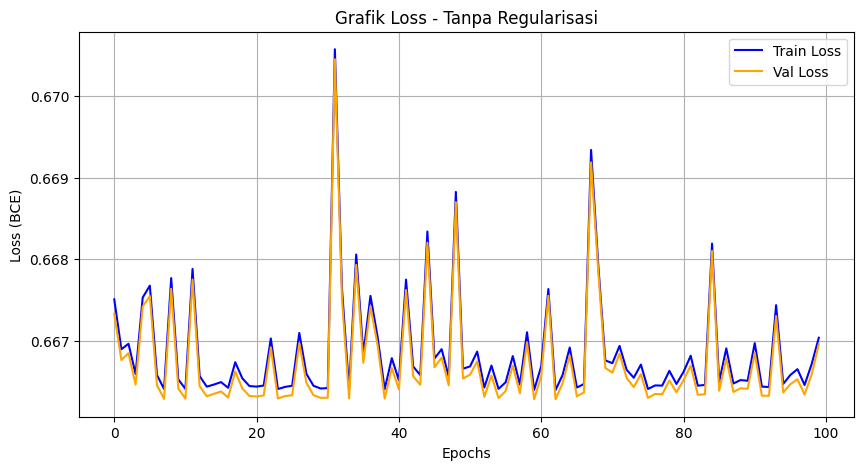

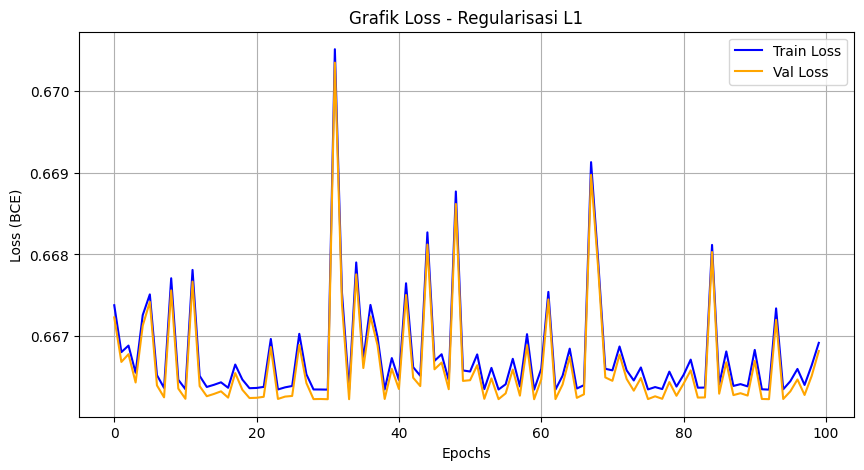

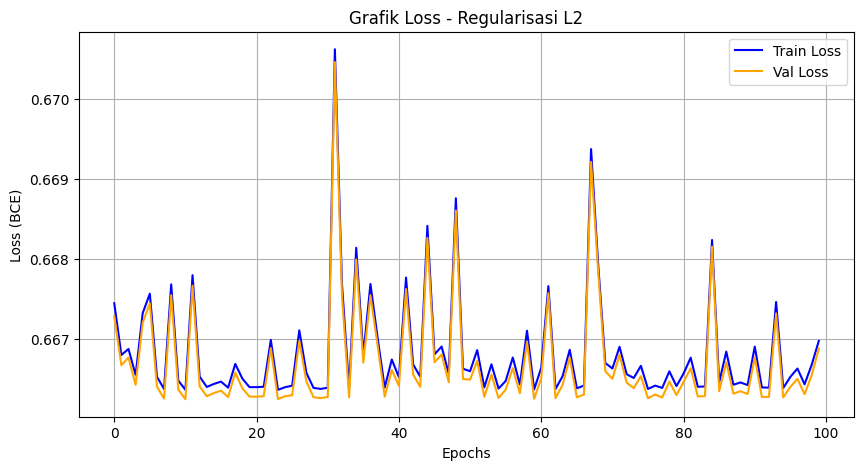

Distribusi untuk Model Tanpa Regularisasi
Distribusi Bobot (Weights)


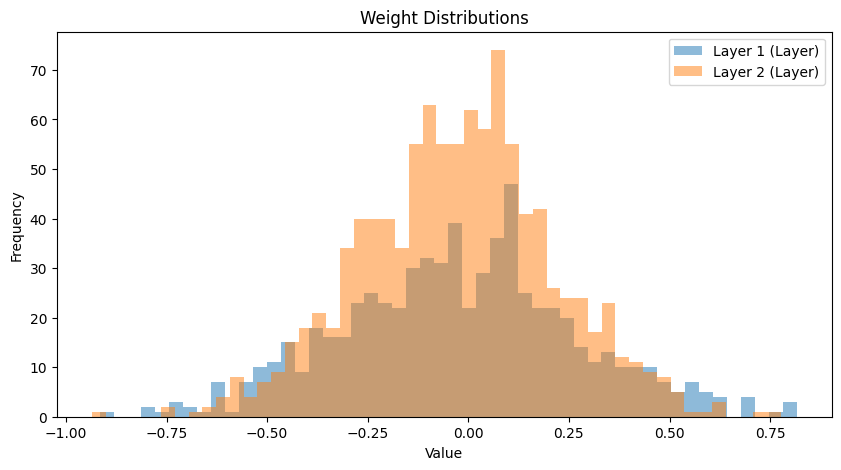

Distribusi Gradien Bobot (Gradients)


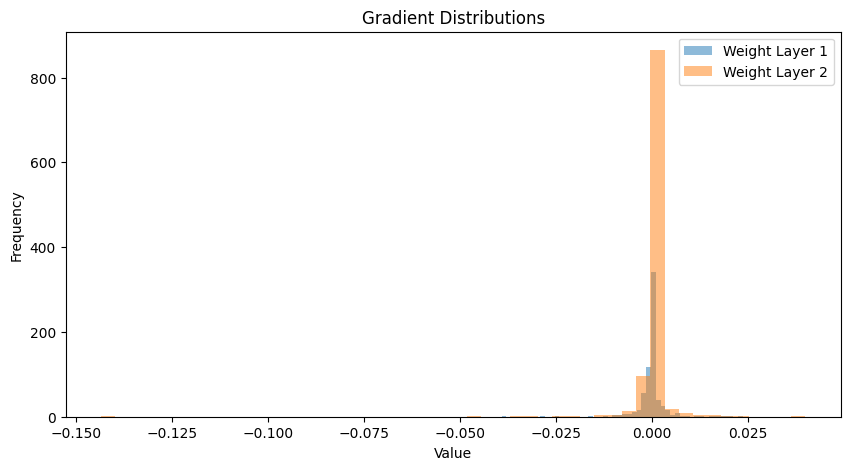

Distribusi untuk Model Regularisasi L1
Distribusi Bobot (Weights)


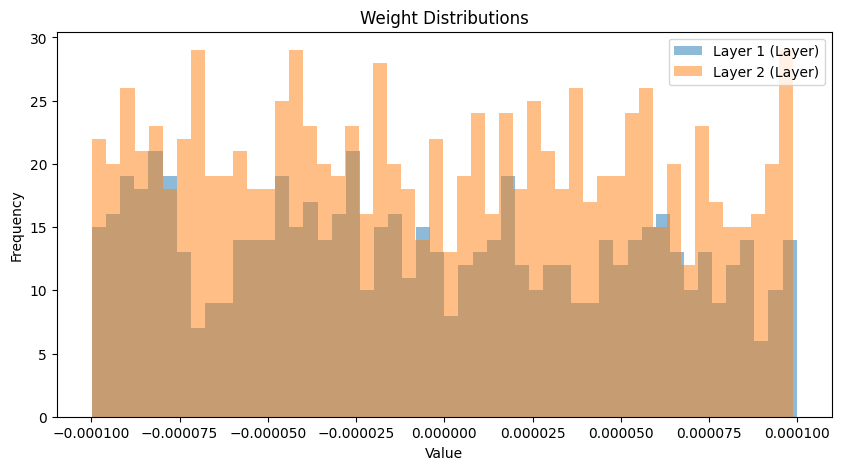

Distribusi Gradien Bobot (Gradients)


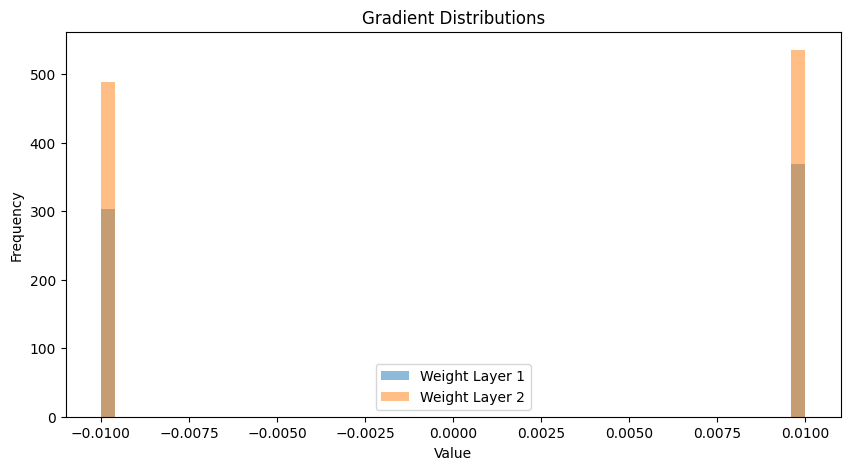

Distribusi untuk Model Regularisasi L2
Distribusi Bobot (Weights)


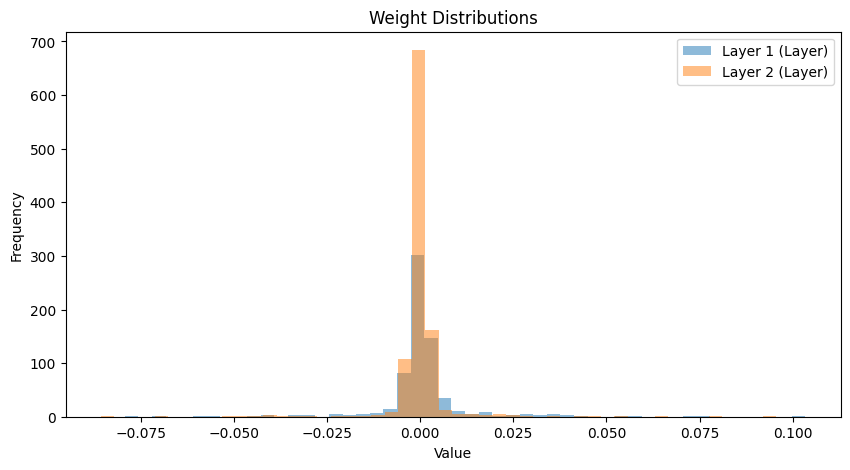

Distribusi Gradien Bobot (Gradients)


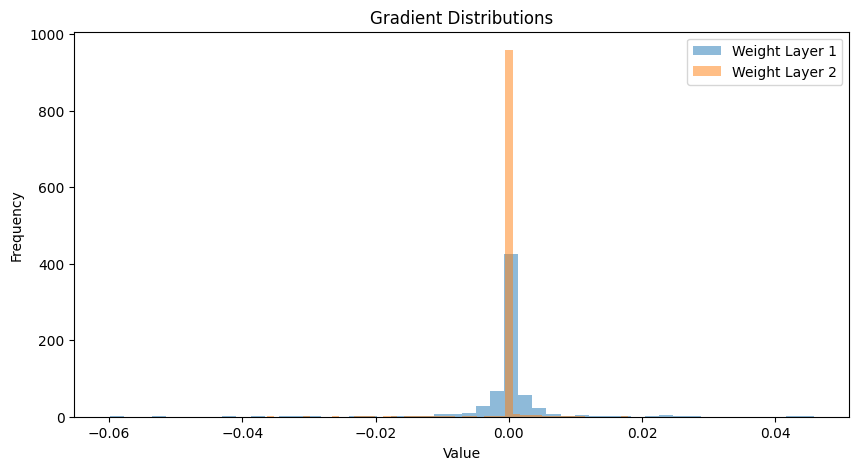

In [13]:
reg_configs = {
    "Tanpa Regularisasi": {"l1": 0.0, "l2": 0.0},
    "Regularisasi L1": {"l1": 0.01, "l2": 0.0},  
    "Regularisasi L2": {"l1": 0.0, "l2": 0.01}
}

all_histories_reg = {}
trained_models_reg = {}

for name, reg in reg_configs.items():
    layers = [
        Layer(32, activation='relu', weight_init='he', l1=reg['l1'], l2=reg['l2']),      
        Layer(32, activation='relu', weight_init='he', l1=reg['l1'], l2=reg['l2']),      
        Layer(1, activation='sigmoid', weight_init='xavier') 
    ]
    
    model = MLP(layers, input_size=X_train.shape[1], seed=42)
    model.compile(optimizer='sgd', loss='bce')
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=100,
        validation_data=(X_val, y_val),
        verbose=0
    )

    all_histories_reg[name] = history
    trained_models_reg[name] = model


# Plot hasil
for name, history in all_histories_reg.items():
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.title(f"Grafik Loss - {name}")
    plt.xlabel('Epochs')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)
    plt.show() 


# Distribusi Bobot dan Gradien
for name, model in trained_models_reg.items():
    print(f"Distribusi untuk Model {name}")
    print(f"Distribusi Bobot (Weights)")
    model.plot_weights([0, 1]) 
    print(f"Distribusi Gradien Bobot (Gradients)")
    model.plot_gradients([0, 1])

    

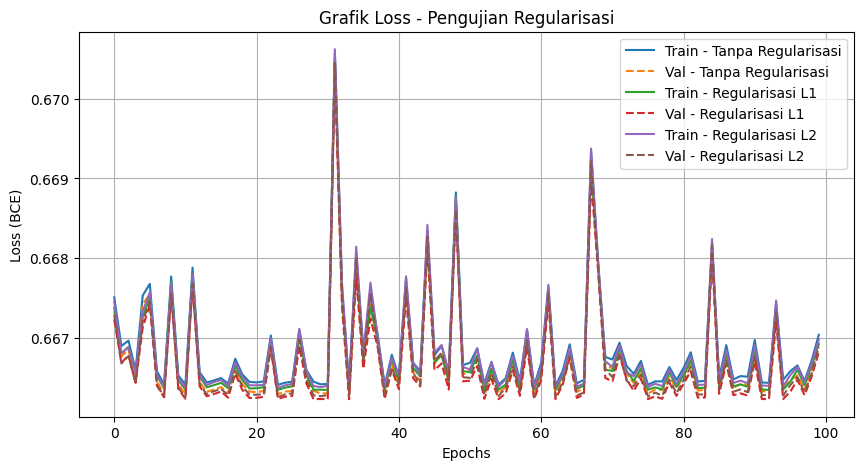

In [26]:
plt.figure(figsize=(10, 5)) 
for name, history in all_histories_reg.items():
    plt.plot(history['train_loss'], label=f'Train - {name}') 
    plt.plot(history['val_loss'], label=f'Val - {name}', linestyle='--')
plt.title(f"Grafik Loss - Pengujian Regularisasi")
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(True)
plt.show() 

# Uji Perbandingan
Analisis perbandingan hasil prediksi dengan library sklearn MLP
- Lakukan satu kali pelatihan dengan hyperparameter yang sama untuk kedua model
- Bandingkan hasil akhir prediksinya saja 

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Model Sklearn
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(32, 32), 
    activation='relu', 
    solver='sgd',
    learning_rate_init=0.01,   
    batch_size=32, 
    max_iter=100, 
    random_state=42 
)

sklearn_model.fit(X_train, y_train)
sklearn_preds = sklearn_model.predict(X_val)
sklearn_accuracy = accuracy_score(y_val, sklearn_preds)
print(f"Akurasi berdasarkan model Sklearn: {sklearn_accuracy:.3f}")

# Model Six-seven
sixseven_layers = [
    Layer(32, activation='relu', weight_init='he'), 
    Layer(32, activation='relu', weight_init='he'),
    Layer(1, activation='sigmoid', weight_init='xavier')
]

sixseven_model = MLP(sixseven_layers, input_size=X_train.shape[1], seed=42)
sixseven_model.compile(optimizer={'method': 'sgd', 'lr': 0.01}, loss='bce')

sixseven_history = sixseven_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=0 
)

sixseven_probs = sixseven_model(X_val).data 
if hasattr(sixseven_probs, 'numpy'): 
    sixseven_probs = sixseven_probs.numpy()

sixseven_preds = (np.array(sixseven_probs) >= 0.5).astype(int).flatten()
sixseven_accuracy = accuracy_score(y_val, sixseven_preds)
print(f"Akurasi berdasarkan model Sixseven: {sixseven_accuracy:.3f}")

# Perbandingan
selisih = abs(sklearn_accuracy - sixseven_accuracy) * 100
print(f"Selisih Performa: {selisih:.2f}%")

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Akurasi berdasarkan model Sklearn: 0.733
Akurasi berdasarkan model Sixseven: 0.616
Selisih Performa: 11.75%
